# **Import libs**

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from scipy.optimize import linear_sum_assignment
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Почему не совпали эти 20% Типов пятен? 

Сопоставить количество совпадений кластеров и 80% классов

Солнце вращается на 12 градусов ежедневно


# **sunspot_data.csv** 
from *https://sunspots.irsol.usi.ch/db/drawing.php?y=2014&m=4&d=16*

In [8]:
df = pd.read_csv('/kaggle/input/sunspot-draw2/sunspot_data.csv',index_col = 0)
# df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
# # df['year'] = df['Date'].dt.year
# # df['month'] = df['Date'].dt.month
# # df['day'] = df['Date'].dt.day

df.reset_index(inplace=True)
df = df[['Дата','Время','Latitude','Carrington Longit.','Type']]
df = df.rename(columns={"Дата": "Date", "Carrington Longit.": "Longitude", "Время":"Time"})
print("Количество строк с отсутсвтвующими значениями:",df.isnull().any(axis=1).sum())
print("Shape:",df.shape)
#df = df[df['Type'] != 'G']
#df = df[df['Type'] != 'J']
df = df.dropna()
df.head(5)

Количество строк с отсутсвтвующими значениями: 3
Shape: (9975, 5)


,Date,Time,Latitude,Longitude,Type
0,2010-01-01,10:00,-28.1,54.9,D
1,2010-01-02,08:30,-28.0,53.9,D
2,2010-01-04,09:00,-28.1,56.2,G
3,2010-01-09,10:00,28.8,238.2,B
4,2010-01-10,10:30,27.6,243.0,D


In [15]:
# plt.figure(figsize=(10, 6))
# plt.scatter(df['Longitude'], df['Latitude'], c='blue', marker='o')

# # Добавление аннотаций
# for i in range(len(df)):
#     plt.annotate(f"{df.iloc[i]['Type']} ({df.iloc[i]['Date']})", 
#                  (df.iloc[i]['Longitude'], df.iloc[i]['Latitude']), 
#                  textcoords="offset points", xytext=(0,10), ha='center')

# plt.title('Visualization of Latitude and Longitude')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.grid()
# plt.xlim(50, 250)  # Установите пределы по оси X в зависимости от ваших данных
# plt.ylim(-30, 30)  # Установите пределы по оси Y в зависимости от ваших данных
# plt.axhline(0, color='black', linewidth=0.5, ls='--')
# plt.axvline(0, color='black', linewidth=0.5, ls='--')
# plt.show()

<Figure size 1000x600 with 0 Axes>

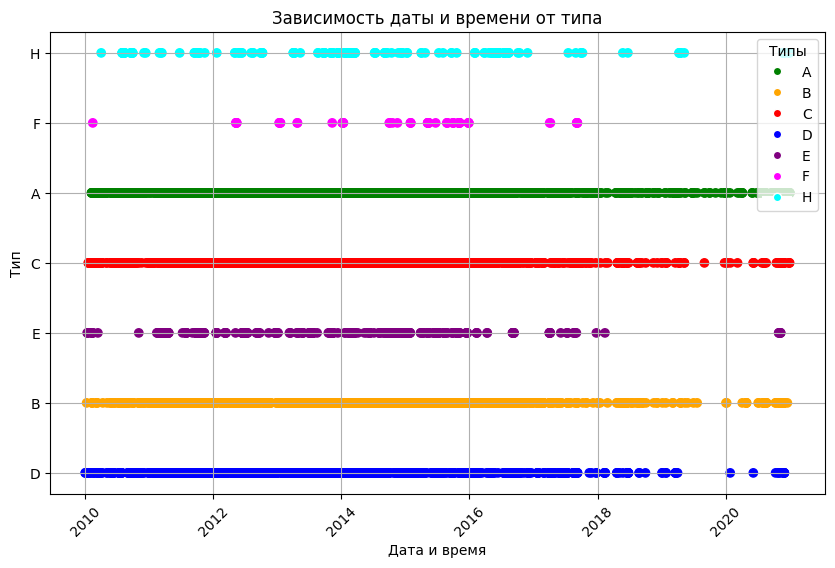

In [3]:
# Преобразуем дату и время в datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Визуализация
plt.figure(figsize=(10, 6))

# Используем разные цвета для разных типов
colors = {
    'A': 'green',
    'B': 'orange',
    'C': 'red',
    'D': 'blue',
    'E': 'purple',
    'F': 'magenta',
    'H': 'cyan'
}

# Создаем колонку с цветами
df['Color'] = df['Type'].apply(lambda x: colors.get(x, 'gray'))  # 'gray' для неизвестных типов

# Визуализация
plt.figure(figsize=(10, 6))

# Создаем график с цветами
scatter = plt.scatter(df['DateTime'], df['Type'], c=df['Color'], marker='o')

# Добавление легенды в верхнем левом углу
handles = [plt.Line2D([0], [0], marker='o', color='w', label=key, 
                       markerfacecolor=value) for key, value in colors.items() if key in df['Type'].unique()]
plt.legend(handles=handles, title="Типы", loc='upper right')

plt.title('Зависимость даты и времени от типа')
plt.xlabel('Дата и время')
plt.ylabel('Тип')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [9]:
pd.read_csv('/kaggle/input/sunspot-group-properties/sunspot_group_properties.csv')

,fname,date,group_number,lat_max,lat_mean,lat_min,long_max,long_mean,long_min,area,nspots,ncores,nspots_with_cores,tilt,complexity,B0,L0
0,201007230452_63,2010-07-23 04:52:00,63,-20.896839,-23.565131,-26.597699,204.043367,200.328655,194.646751,489.292797,17,16,6,-2.385188,210,5.0,230.3
1,201007240414_63,2010-07-24 04:14:00,63,-21.131845,-23.933526,-27.108871,204.704703,201.274268,194.511357,303.408179,9,4,3,-23.918642,241,5.1,217.4
2,201007250447_64,2010-07-25 04:47:00,64,23.580196,23.339903,23.101008,149.500812,149.048761,148.527835,16.553683,1,0,0,3.633730,78,5.2,203.9
3,201007250447_63,2010-07-25 04:47:00,63,-20.642013,-23.509269,-26.938974,204.949343,201.557542,195.071475,297.469260,12,7,3,-32.418379,232,5.2,203.9
4,201007260349_63,2010-07-26 03:49:00,63,-20.258757,-23.032369,-26.887540,205.544796,202.530956,198.138547,193.869511,9,3,2,-40.638848,255,5.0,191.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8493,202008120532_31,2020-08-12 05:32:00,31,23.913506,23.744530,23.590821,23.358192,23.202173,23.017393,3.627088,1,1,1,-20.556045,24,6.5,350.2
8494,202008120532_33,2020-08-12 05:32:00,33,-18.919818,-19.017301,-19.124511,297.120542,296.952145,296.788714,3.165966,1,0,0,15.018361,19,6.5,350.2
8495,202008180351_34,2020-08-18 03:51:00,34,18.506278,18.293351,18.088359,296.554881,296.295343,296.019040,8.938790,1,1,1,-6.980488,44,6.8,271.9
8496,202008190344_35,2020-08-19 03:44:00,35,16.197485,15.355416,14.602672,254.801501,254.371843,253.992354,5.245143,2,0,0,-68.521065,50,6.8,258.7


# **sunspot_group_properties.csv** 
a dataset of sunspot groups observed at the Kislovodsk Mountain Astronomical Station for the period 2010--2020
from *https://github.com/observethesun/sunspot_groups*

In [5]:
pd.read_csv('/kaggle/input/sunspot-group-properties/sunspot_group_properties.csv')

,fname,date,group_number,lat_max,lat_mean,lat_min,long_max,long_mean,long_min,area,nspots,ncores,nspots_with_cores,tilt,complexity,B0,L0
0,201007230452_63,2010-07-23 04:52:00,63,-20.896839,-23.565131,-26.597699,204.043367,200.328655,194.646751,489.292797,17,16,6,-2.385188,210,5.0,230.3
1,201007240414_63,2010-07-24 04:14:00,63,-21.131845,-23.933526,-27.108871,204.704703,201.274268,194.511357,303.408179,9,4,3,-23.918642,241,5.1,217.4
2,201007250447_64,2010-07-25 04:47:00,64,23.580196,23.339903,23.101008,149.500812,149.048761,148.527835,16.553683,1,0,0,3.633730,78,5.2,203.9
3,201007250447_63,2010-07-25 04:47:00,63,-20.642013,-23.509269,-26.938974,204.949343,201.557542,195.071475,297.469260,12,7,3,-32.418379,232,5.2,203.9
4,201007260349_63,2010-07-26 03:49:00,63,-20.258757,-23.032369,-26.887540,205.544796,202.530956,198.138547,193.869511,9,3,2,-40.638848,255,5.0,191.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8493,202008120532_31,2020-08-12 05:32:00,31,23.913506,23.744530,23.590821,23.358192,23.202173,23.017393,3.627088,1,1,1,-20.556045,24,6.5,350.2
8494,202008120532_33,2020-08-12 05:32:00,33,-18.919818,-19.017301,-19.124511,297.120542,296.952145,296.788714,3.165966,1,0,0,15.018361,19,6.5,350.2
8495,202008180351_34,2020-08-18 03:51:00,34,18.506278,18.293351,18.088359,296.554881,296.295343,296.019040,8.938790,1,1,1,-6.980488,44,6.8,271.9
8496,202008190344_35,2020-08-19 03:44:00,35,16.197485,15.355416,14.602672,254.801501,254.371843,253.992354,5.245143,2,0,0,-68.521065,50,6.8,258.7


In [6]:
df2 = pd.read_csv('/kaggle/input/sunspot-group-properties/sunspot_group_properties.csv')
df2 = df2[['fname','date','lat_mean','long_mean']]
#df2 = df2[['fname','date','lat_mean','long_mean', 'lat_max'	,	'lat_min'	,'long_max'	,	'long_min']]

def transform_fname(fname):
    date_str = fname[:8] 
    time_str = fname[8:12]  
    formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"

    hour = time_str[:2]
    minute = time_str[2:6]
    formatted_time = f"{hour}:{minute}"
    return formatted_date, formatted_time

df2[['transf_date', 'time']] = df2['fname'].apply(lambda x: pd.Series(transform_fname(x)))
print("Количество строк с отсутсвтвующими значениями:",df2.isnull().any(axis=1).sum())
print("Shape:",df2.shape)

# df2['fname'] = df2['fname'].str[:8].astype('int64')
#df2['fname'] = pd.to_datetime(df2['fname'], format='%Y%m%d')
# #df.loc[:,'Date'] 
# df2['fname'] = pd.to_datetime(df2['fname']).astype(int) / 10**9  # Преобразуем в секунды
# df2 = df2.dropna()
df2 = df2[['fname','transf_date','time','lat_mean','long_mean']]
df2 = df2.rename(columns={"transf_date": "Date", "long_mean": "Longitude", "time":"Time","lat_mean":"Latitude"})
df2 = df2.rename(columns={"transf_date": "Date", "time":"Time"})
df2.head(5)

Количество строк с отсутсвтвующими значениями: 0
Shape: (8498, 6)


,fname,Date,Time,Latitude,Longitude
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956


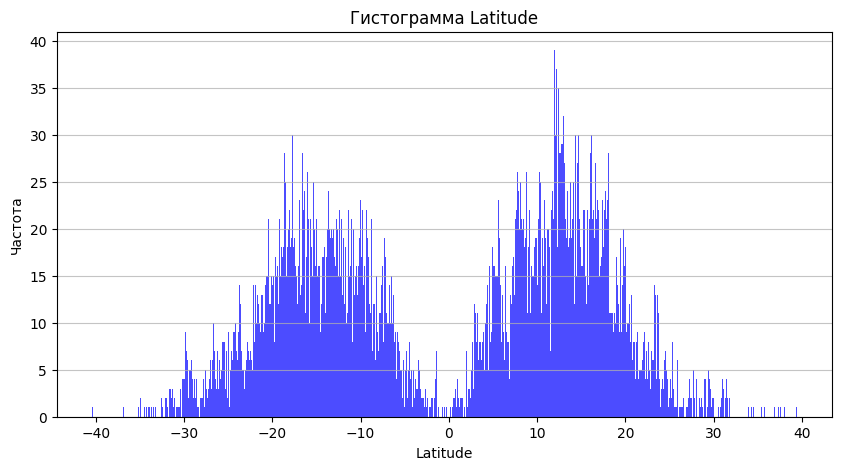

In [32]:
# Построение гистограммы для Latitude
plt.figure(figsize=(10, 5))
plt.hist(df2['Latitude'], bins=1000, color='blue', alpha=0.7)
plt.title('Гистограмма Latitude')
plt.xlabel('Latitude')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

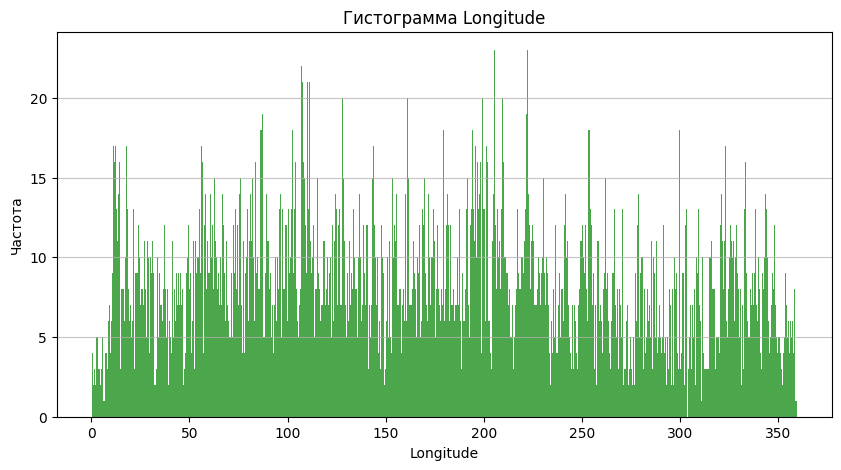

In [31]:
# Построение гистограммы для Longitude
plt.figure(figsize=(10, 5))
plt.hist(df2['Longitude'], bins=1000, color='green', alpha=0.7)
plt.title('Гистограмма Longitude')
plt.xlabel('Longitude')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

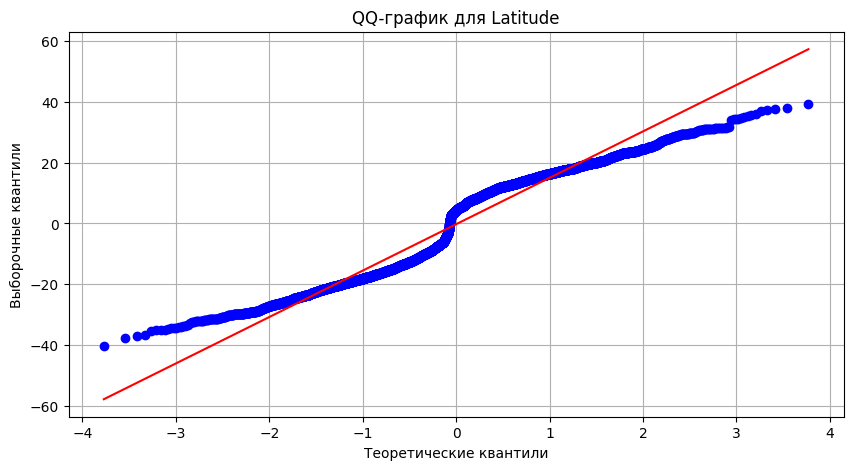

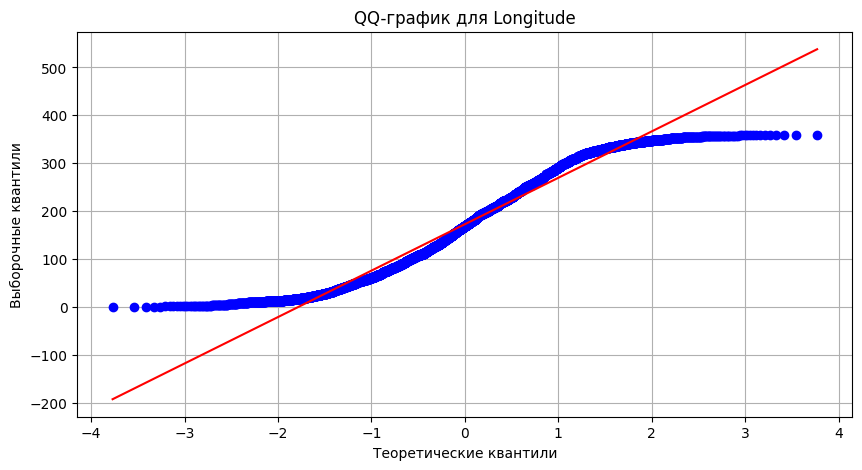

In [33]:
# QQ-график для Latitude
plt.figure(figsize=(10, 5))
stats.probplot(df2['Latitude'], dist="norm", plot=plt)
plt.title('QQ-график для Latitude')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')
plt.grid()
plt.show()

# QQ-график для Longitude
plt.figure(figsize=(10, 5))
stats.probplot(df2['Longitude'], dist="norm", plot=plt)
plt.title('QQ-график для Longitude')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')
plt.grid()
plt.show()

# **процедура сопоставления типов**

In [6]:
df2['Type'].isnull().sum()

1730

In [9]:
def determine_type(row):
    lat = row['Latitude']
    long = row['Longitude']
    date = row['Date']
    time = row['Time']
    
    # 1. Полное совпадение по времени, дате, широте и долготе
    matches = df[
        (df['Time'] == time) & 
        (df['Date'] == date) & 
        (df['Latitude'] == lat) & 
        (df['Longitude'] == long)
    ]
    
    if not matches.empty:
        return matches.iloc[0]['Type']
    
    # 2. Совпадение по дате, широте и долготе
    matches = df[
        (df['Date'] == date) & 
        (df['Latitude'] == lat) & 
        (df['Longitude'].between(long - 0.1, long + 0.1))  
    ]
    
    if not matches.empty:
        return matches.iloc[0]['Type']
    
    matches = df[
        (df['Date'] == date) & 
        (df['Longitude'] == long) & 
        (df['Latitude'].between(lat - 0.1, lat + 0.1)) 
    ]
    
    if not matches.empty:
        return matches.iloc[0]['Type']

    # 3. Совпадение по дате и широте/долготе ±5 градусов
    matches = df[
        (df['Date'] == date) & 
        (df['Latitude'].between(lat - 5, lat + 5)) & 
        (df['Longitude'].between(long - 5, long + 5))
    ]
    
    if not matches.empty:
        return matches.iloc[0]['Type']

    # 4. Совпадение по широте/долготе ±5 градусов и дате ±1 день
    date_minus_1 = pd.to_datetime(date) - pd.Timedelta(days=1)
    date_plus_1 = pd.to_datetime(date) + pd.Timedelta(days=1)

    matches = df[
        (df['Date'].between(date_minus_1.strftime('%Y-%m-%d'), date_plus_1.strftime('%Y-%m-%d'))) & 
        (df['Latitude'].between(lat - 5, lat + 5)) & 
        (df['Longitude'].between(long - 5, long + 5))
    ]

    if not matches.empty:
        return matches.iloc[0]['Type']
    # 5. Совпадение по широте/долготе ±10 градусов и дате ±1 день
    date_minus_1 = pd.to_datetime(date) - pd.Timedelta(days=1)
    date_plus_1 = pd.to_datetime(date) + pd.Timedelta(days=1)

    matches = df[
        (df['Date'].between(date_minus_1.strftime('%Y-%m-%d'), date_plus_1.strftime('%Y-%m-%d'))) & 
        (df['Latitude'].between(lat - 10, lat + 10)) & 
        (df['Longitude'].between(long - 10, long + 10))
    ]

    if not matches.empty:
        return matches.iloc[0]['Type']
    return None  
    
    # 6. Совпадение по широте/долготе ±15 градусов и дате ±2 дня
    date_minus_2 = pd.to_datetime(date) - pd.Timedelta(days=2)
    date_plus_2 = pd.to_datetime(date) + pd.Timedelta(days=2)

    matches = df[
        (df['Date'].between(date_minus_2.strftime('%Y-%m-%d'), date_plus_2.strftime('%Y-%m-%d'))) & 
        (df['Latitude'].between(lat - 15, lat + 15)) & 
        (df['Longitude'].between(long - 15, long + 15))
    ]

    if not matches.empty:
        return matches.iloc[0]['Type']
    return None  

    # 7. Совпадение по широте/долготе ±20 градусов и дате ±2 дня
    date_minus_2 = pd.to_datetime(date) - pd.Timedelta(days=2)
    date_plus_2 = pd.to_datetime(date) + pd.Timedelta(days=2)

    matches = df[
        (df['Date'].between(date_minus_2.strftime('%Y-%m-%d'), date_plus_2.strftime('%Y-%m-%d'))) & 
        (df['Latitude'].between(lat - 20, lat + 20)) & 
        (df['Longitude'].between(long - 20, long + 20))
    ]

    if not matches.empty:
        return matches.iloc[0]['Type']
    return None  

#df2['Type'] = df2.apply(determine_type, axis=1)

dff = df2
dff['Type'] = df2.apply(determine_type, axis=1)
dff

,fname,Date,Time,Latitude,Longitude,Type
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655,D
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268,D
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761,B
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542,D
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956,D
...,...,...,...,...,...,...
8493,202008120532_31,2020-08-12,05:32,23.744530,23.202173,A
8494,202008120532_33,2020-08-12,05:32,-19.017301,296.952145,B
8495,202008180351_34,2020-08-18,03:51,18.293351,296.295343,C
8496,202008190344_35,2020-08-19,03:44,15.355416,254.371843,None


In [10]:
dff.to_csv('/kaggle/working/merge_type_sunspots.csv', index=True)

In [5]:
dff['Type'].value_counts()

Type
C    1782
A    1450
J    1388
D    1377
B    1141
E     202
H     134
G      34
F      12
Name: count, dtype: int64

In [6]:
dff['Type'].isnull().sum()

978

In [36]:
df2.shape[0]

8498

In [35]:
print(f"Доля несовпадений типов {dff['Type'].isnull().sum() / df2.shape[0] }")

Доля несовпадений типов 0.11508590256530948


In [41]:
dff[dff['Type'].isna()]

,fname,date,Latitude,Longitude,Date,Time,Type
79,201009240428_86,2010-09-24 04:28:00,21.377109,83.665956,2010-09-24,04:28,None
114,201010190512_92,2010-10-19 05:12:00,16.346180,94.747997,2010-10-19,05:12,None
129,201010240525_95,2010-10-24 05:25:00,20.732866,59.849551,2010-10-24,05:25,None
130,201010240525_92,2010-10-24 05:25:00,22.642916,96.202847,2010-10-24,05:25,None
131,201010240525_90,2010-10-24 05:25:00,-29.417120,122.475224,2010-10-24,05:25,None
...,...,...,...,...,...,...,...
8470,202006110341_17,2020-06-11 03:41:00,-25.093259,113.285827,2020-06-11,03:41,None
8471,202006120254_18,2020-06-12 02:54:00,24.558457,101.870607,2020-06-12,02:54,None
8478,202007180315_27,2020-07-18 03:15:00,-20.393761,315.439480,2020-07-18,03:15,None
8489,202008070320_32,2020-08-07 03:20:00,-16.889023,54.814456,2020-08-07,03:20,None


# **анализ данных без типа группы**

In [6]:
#none_type_df = dff[dff['Type'].isnull()]

observe = pd.read_csv('/kaggle/input/type-sunspots-zurich/merge_type_sunspots.csv',index_col = 0)
none_type_df = observe[observe['Type'].isnull()]
none_type_df.head()

,fname,Date,Time,Latitude,Longitude,Type
79,201009240428_86,2010-09-24,04:28,21.377109,83.665956,NaN
114,201010190512_92,2010-10-19,05:12,16.346180,94.747997,NaN
129,201010240525_95,2010-10-24,05:25,20.732866,59.849551,NaN
130,201010240525_92,2010-10-24,05:25,22.642916,96.202847,NaN
131,201010240525_90,2010-10-24,05:25,-29.417120,122.475224,NaN


In [23]:
observe[observe['Type'].notnull()]

,fname,Date,Time,Latitude,Longitude,Type
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655,D
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268,D
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761,B
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542,D
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956,D
...,...,...,...,...,...,...
8492,202008100346_31,2020-08-10,03:46,23.201436,23.490231,J
8493,202008120532_31,2020-08-12,05:32,23.744530,23.202173,A
8494,202008120532_33,2020-08-12,05:32,-19.017301,296.952145,B
8495,202008180351_34,2020-08-18,03:51,18.293351,296.295343,C


In [92]:
none_type_df.describe(include='all')

<ipython-input-92-af4315684c8e>:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  none_type_df.describe(include='all')
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,fname,date,Latitude,Longitude,Date,Time,Type
count,978,978,978.000000,978.000000,978,978,0
unique,978,522,NaN,NaN,522,272,0
top,201009240428_86,2014-07-07 03:48:00,NaN,NaN,2014-07-07 00:00:00,05:31,NaN
freq,1,11,NaN,NaN,11,17,NaN
mean,NaN,NaN,-1.370614,179.872758,NaN,NaN,NaN
std,NaN,NaN,16.189435,101.653471,NaN,NaN,NaN
min,NaN,NaN,-36.895874,0.712035,NaN,NaN,NaN
25%,NaN,NaN,-15.209045,98.514557,NaN,NaN,NaN
50%,NaN,NaN,-2.495487,179.783578,NaN,NaN,NaN
75%,NaN,NaN,13.164650,268.153744,NaN,NaN,NaN


In [97]:
#unique_dates = none_type_df['Date'].unique()
unique_time = none_type_df['Time'].unique()
#print("Уникальные даты:", unique_dates)
print("Уникальное время:", unique_time)

Уникальное время: ['04:28' '05:12' '05:25' '05:16' '05:07' '04:56' '05:31' '07:19' '06:24'
 '07:00' '07:23' '06:09' '06:19' '06:11' '05:57' '09:15' '09:26' '08:56'
 '05:44' '08:39' '06:16' '07:02' '07:22' '06:59' '06:05' '05:51' '06:10'
 '09:54' '06:12' '05:58' '06:15' '04:54' '04:25' '04:27' '04:02' '03:59'
 '06:00' '07:13' '03:27' '03:23' '08:08' '03:33' '03:25' '05:19' '03:51'
 '03:14' '03:19' '03:09' '03:18' '03:38' '03:36' '04:12' '04:14' '04:03'
 '04:58' '03:45' '07:20' '04:46' '09:22' '08:01' '12:11' '05:05' '04:08'
 '07:14' '04:35' '04:22' '07:26' '07:24' '06:18' '06:31' '07:41' '06:35'
 '07:39' '08:45' '06:41' '09:25' '06:32' '06:38' '06:34' '06:30' '05:47'
 '06:57' '04:52' '04:09' '06:29' '03:44' '03:39' '03:35' '08:31' '03:46'
 '09:10' '03:26' '03:47' '04:42' '07:40' '03:55' '02:57' '04:40' '04:30'
 '03:32' '04:05' '05:22' '03:04' '03:21' '03:07' '05:55' '03:34' '04:15'
 '04:32' '04:49' '05:26' '03:50' '04:17' '06:26' '06:03' '04:41' '04:26'
 '07:57' '11:58' '04:29' '04:44' 

In [18]:
#time_counts = none_type_df['Time'].value_counts().reset_index()
time_counts.sort_values(by=['Time'])

,Time,Count
271,02:54,1
222,02:57,1
214,03:00,1
216,03:01,1
173,03:04,2
...,...,...
178,10:46,1
205,10:51,1
242,11:38,1
143,11:58,2


      Time  count
271  02:54      1
222  02:57      1
214  03:00      1
216  03:01      1
173  03:04      2
..     ...    ...
178  10:46      1
205  10:51      1
242  11:38      1
143  11:58      2
264  12:11      1

[272 rows x 2 columns]


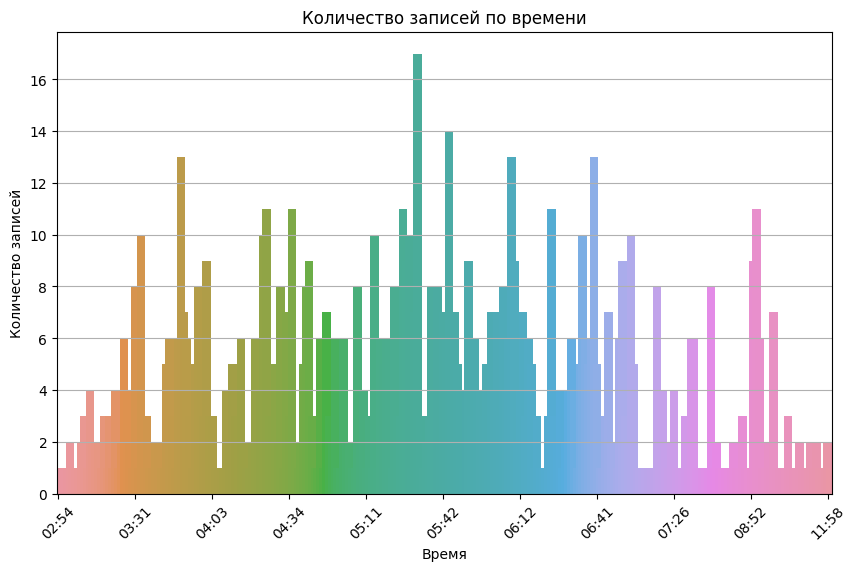

In [19]:
time_counts = none_type_df['Time'].value_counts().reset_index().sort_values(by=['Time'])
print(time_counts)

time_counts_df = time_counts#.sort_index()#.reset_index()
time_counts_df.columns = ['Time', 'Count']

# Построение графика
plt.figure(figsize=(10, 6))
sns.barplot(x='Time', y='Count', data=time_counts_df, width=3)

# Установка заголовка и меток осей
plt.title('Количество записей по времени')
plt.xlabel('Время')
plt.ylabel('Количество записей')


xticks = time_counts_df['Time'].unique()
num_xticks = len(xticks)
if num_xticks > 10:
    plt.xticks(ticks=range(0, num_xticks, num_xticks // 10), 
               labels=xticks[::num_xticks // 10], rotation=45)
else:
    plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

      Time  count
456  02:25      1
434  02:31      1
446  02:32      1
414  02:33      2
463  02:36      1
..     ...    ...
419  13:26      2
399  13:31      3
350  13:50      5
420  13:57      2
307  14:45      7

[464 rows x 2 columns]


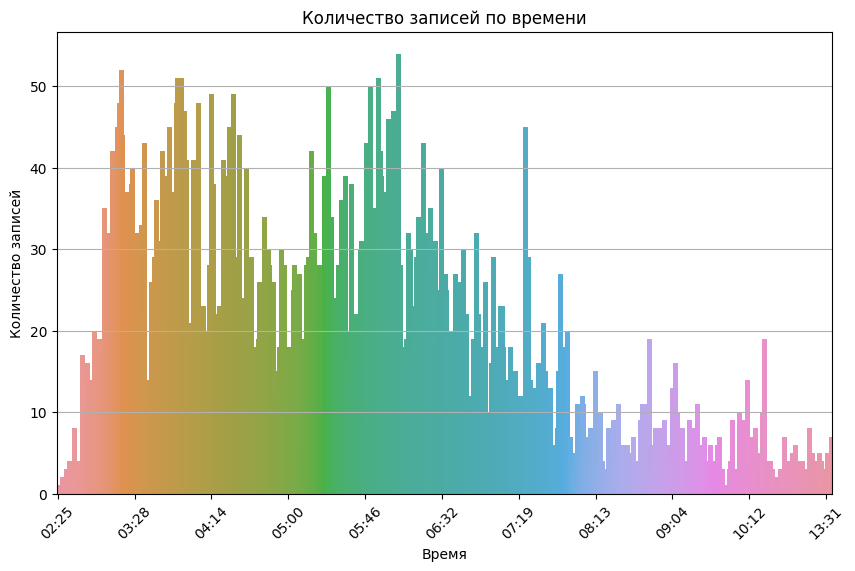

In [24]:
time_counts = observe[observe['Type'].notnull()]['Time'].value_counts().reset_index().sort_values(by=['Time'])
print(time_counts)

time_counts_df = time_counts#.sort_index()#.reset_index()
time_counts_df.columns = ['Time', 'Count']

# Построение графика
plt.figure(figsize=(10, 6))
sns.barplot(x='Time', y='Count', data=time_counts_df, width=3)

# Установка заголовка и меток осей
plt.title('Количество записей по времени')
plt.xlabel('Время')
plt.ylabel('Количество записей')


xticks = time_counts_df['Time'].unique()
num_xticks = len(xticks)
if num_xticks > 10:
    plt.xticks(ticks=range(0, num_xticks, num_xticks // 10), 
               labels=xticks[::num_xticks // 10], rotation=45)
else:
    plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

      Time  count
451  02:25      1
445  02:31      1
442  02:32      1
439  02:33      2
466  02:36      1
..     ...    ...
432  13:26      2
410  13:31      3
354  13:50      5
425  13:57      2
335  14:45      7

[467 rows x 2 columns]


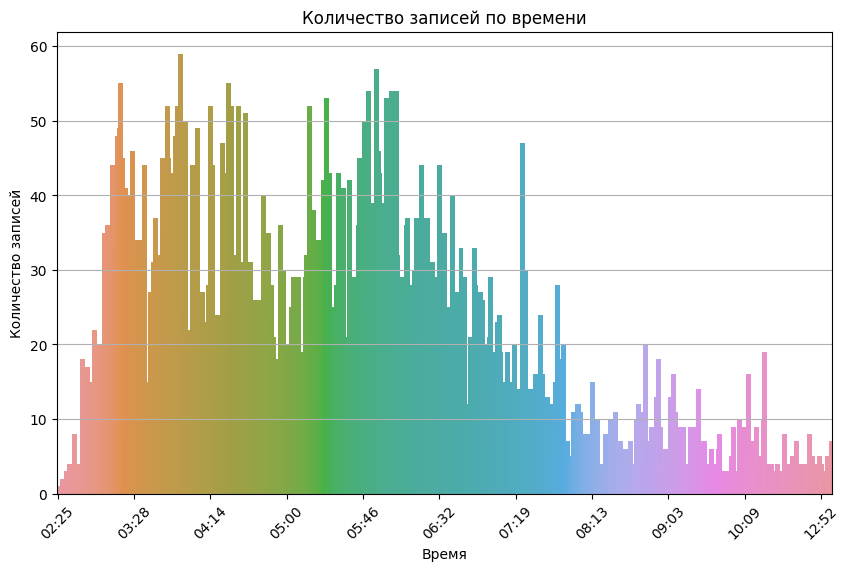

In [20]:
time_counts = observe['Time'].value_counts().reset_index().sort_values(by=['Time'])
print(time_counts)

time_counts_df = time_counts#.sort_index()#.reset_index()
time_counts_df.columns = ['Time', 'Count']

# Построение графика
plt.figure(figsize=(10, 6))
sns.barplot(x='Time', y='Count', data=time_counts_df, width=3)

# Установка заголовка и меток осей
plt.title('Количество записей по времени')
plt.xlabel('Время')
plt.ylabel('Количество записей')


xticks = time_counts_df['Time'].unique()
num_xticks = len(xticks)
if num_xticks > 10:
    plt.xticks(ticks=range(0, num_xticks, num_xticks // 10), 
               labels=xticks[::num_xticks // 10], rotation=45)
else:
    plt.xticks(rotation=45)

plt.grid(axis='y')
plt.show()

# **Кластеры 6**

In [14]:
def transform_fname(fname):
    date_str = fname[:8] 
    time_str = fname[8:12]  
    formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"

    hour = time_str[:2]
    minute = time_str[2:6]
    formatted_time = f"{hour}:{minute}"
    return formatted_date, formatted_time


clust = pd.read_csv('/kaggle/input/update-vae-clusters/update_vae_clusters.csv',index_col = 0).reset_index()
clust[['transf_date', 'time']] = clust['index'].apply(lambda x: pd.Series(transform_fname(x)))

# df = df[['Дата','Время','Latitude','Carrington Longit.','Type']]
# df = df.rename(columns={"Дата": "Date", "Carrington Longit.": "Longitude", "Время":"Time"})
print("Количество строк с отсутсвтвующими значениями:",clust.isnull().any(axis=1).sum())
print("Shape:",clust.shape)

clust.head(5)

Количество строк с отсутсвтвующими значениями: 0
Shape: (8498, 4)


,index,cluster_vae,transf_date,time
0,201007230452_63,6,2010-07-23,04:52
1,201007240414_63,3,2010-07-24,04:14
2,201007250447_63,3,2010-07-25,04:47
3,201007250447_64,1,2010-07-25,04:47
4,201007260349_63,5,2010-07-26,03:49


# **Кластеры 10**

In [3]:
def transform_fname(fname):
    date_str = fname[:8] 
    time_str = fname[8:12]  
    formatted_date = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]}"

    hour = time_str[:2]
    minute = time_str[2:6]
    formatted_time = f"{hour}:{minute}"
    return formatted_date, formatted_time


clust = pd.read_csv('/kaggle/input/vae-10-clusters-pca/VAE_10_clusters_pca.csv',index_col = 0).reset_index()
clust[['transf_date', 'time']] = clust['index'].apply(lambda x: pd.Series(transform_fname(x)))

# df = df[['Дата','Время','Latitude','Carrington Longit.','Type']]
# df = df.rename(columns={"Дата": "Date", "Carrington Longit.": "Longitude", "Время":"Time"})
print("Количество строк с отсутсвтвующими значениями:",clust.isnull().any(axis=1).sum())
print("Shape:",clust.shape)

clust

Количество строк с отсутсвтвующими значениями: 0
Shape: (8498, 6)


,index,Component 1,Component 2,cluster,transf_date,time
0,201007230452_63,4.837387,1.577543,4,2010-07-23,04:52
1,201007240414_63,4.089237,-1.180101,2,2010-07-24,04:14
2,201007250447_63,4.571561,-1.045237,2,2010-07-25,04:47
3,201007250447_64,-3.809086,-1.841704,5,2010-07-25,04:47
4,201007260349_63,-0.976733,0.182294,10,2010-07-26,03:49
...,...,...,...,...,...,...
8493,202008120532_31,-3.582883,-2.460317,5,2020-08-12,05:32
8494,202008120532_33,-3.117127,-1.987413,5,2020-08-12,05:32
8495,202008180351_34,-4.113935,-2.709833,5,2020-08-18,03:51
8496,202008190344_34,0.608996,-0.473129,1,2020-08-19,03:44


# **Классы из Цюрихской обсерватории**

In [6]:
observe = pd.read_csv('/kaggle/input/type-sunspots-zurich/merge_type_sunspots.csv',index_col = 0)

replacement_dict_observe = {None: 'Unknown'}

observe['Type'] = observe['Type'].replace(replacement_dict_observe)

print("Количество распознанных классов + нераспознанные",observe.shape[0])
observe = observe[observe['Type'] != 'Unknown']
print("Количество распознанных классов",observe.shape[0])
observe.head()

Количество распознанных классов + нераспознанные 8498
Количество распознанных классов 7520


,fname,Date,Time,Latitude,Longitude,Type
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655,D
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268,D
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761,B
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542,D
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956,D


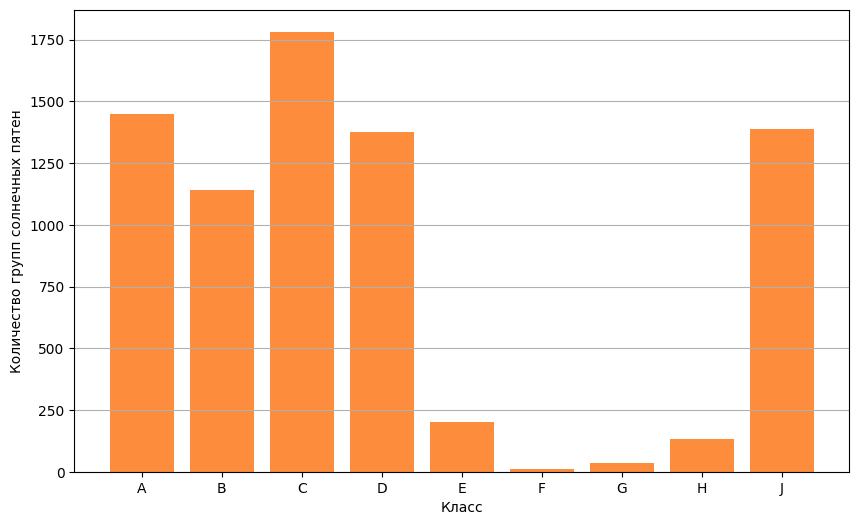

In [10]:
observe_type = observe['Type'].value_counts().reset_index().sort_values(by='Type')

plt.figure(figsize=(10, 6))
plt.bar(observe_type['Type'], observe_type['count'], color='#FD8D3C')
plt.xlabel('Класс')
plt.ylabel('Количество групп солнечных пятен')
#plt.title('Количество групп солнечных пятен по классам пятен')
#plt.xticks(rotation=45)
plt.grid(axis='y')

plt.savefig('/kaggle/working/count_sunspot_types.jpg')
# Показать диаграмму
plt.show()

In [17]:
observe_type

,Type,count
1,A,1450
4,B,1141
0,C,1782
3,D,1377
5,E,202
8,F,12
7,G,34
6,H,134
2,J,1388


# **Сопоставление классов:** 
* полученных с помощью кластеризации
* определенных в обсерватории

In [5]:
link = pd.merge(observe,clust, how='left', left_on='fname', right_on='index')
link = link[['fname','Date','Time','Latitude','Longitude','Type','cluster']]
link.head()

,fname,Date,Time,Latitude,Longitude,Type,cluster
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655,D,4
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268,D,2
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761,B,5
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542,D,2
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956,D,10


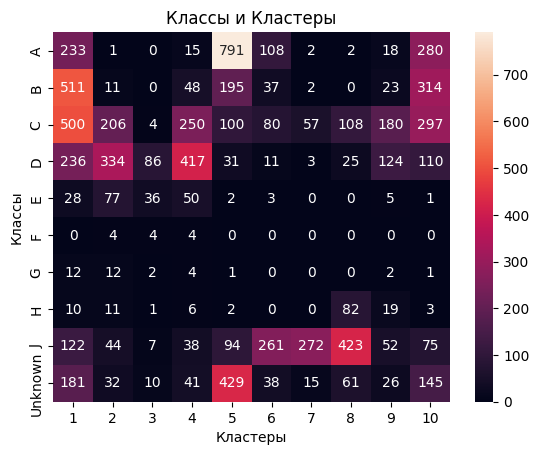

In [6]:
# Расчет перекрестной таблицы
crosstab = pd.crosstab(link['Type'], link['cluster'])

sns.heatmap(crosstab, annot=True, fmt='d')
plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')
plt.show()

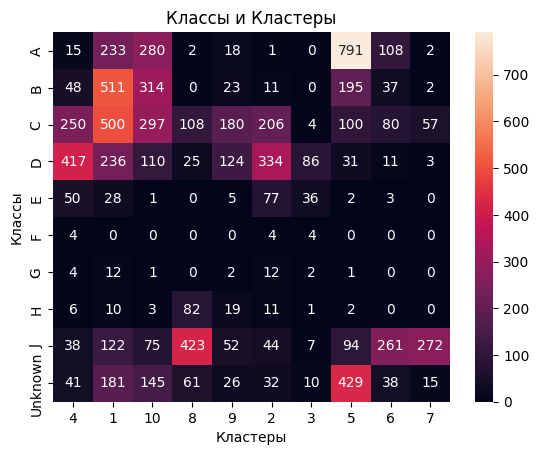

In [7]:
diagonal_values = crosstab.values.diagonal()

diagonal_df = pd.DataFrame({
    'cluster': crosstab.columns,
    'max_intersection': diagonal_values
})

# Сортируем кластеры по значениям на главной диагонали в порядке убывания
sorted_clusters = diagonal_df.sort_values(by='max_intersection', ascending=False)['cluster']

crosstab_sorted = crosstab[sorted_clusters]

# Создаем тепловую карту
sns.heatmap(crosstab_sorted, annot=True, fmt='d')
plt.title('Классы и Кластеры')
plt.xlabel('Кластеры')
plt.ylabel('Классы')
plt.show()

In [53]:
#  Группировка данных по типу и кластеру
grouped_data = link.groupby(['Type', 'cluster']).size().reset_index(name='Count')

In [54]:
grouped_data

,Type,cluster,Count
0,A,1,233
1,A,2,1
2,A,4,15
3,A,5,791
4,A,6,108
...,...,...,...
78,Unknown,6,38
79,Unknown,7,15
80,Unknown,8,61
81,Unknown,9,26


In [65]:
cluster_type = link.groupby(['cluster', 'Type']).size().unstack(fill_value=0)

cluster_stats = link.groupby('cluster').agg({
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Type': lambda x: x.mode()[0] if len(x.mode()) > 0 else None
}).reset_index()
cluster_stats

,cluster,Latitude,Longitude,Type
0,1,0.349740,173.607533,B
1,2,-0.728417,177.082167,D
2,3,-0.818316,175.797794,D
3,4,-1.743384,173.350906,D
4,5,-0.360091,174.301989,A
5,6,0.603672,169.631076,J
6,7,1.454588,169.402101,J
7,8,0.139881,156.417799,J
8,9,-0.376312,179.230349,C
9,10,-0.540489,175.386457,B


In [68]:
mean_coords = link.groupby('cluster').agg({
    'Latitude': ['min','max','mean', 'std'],
    'Longitude': ['mean', 'std']
}).round(2)

print("\nСредние координаты кластеров:")
mean_coords


Средние координаты кластеров:


Latitude                     Longitude        
             min    max  mean    std      mean     std
cluster                                               
1         -34.03  39.42  0.35  15.77    173.61   98.39
2         -31.59  33.93 -0.73  15.16    177.08   92.38
3         -24.41  23.45 -0.82  13.77    175.80   94.82
4         -31.28  31.14 -1.74  15.65    173.35   98.68
5         -40.42  36.16 -0.36  15.84    174.30   99.73
6         -33.75  31.78  0.60  16.26    169.63  101.41
7         -32.16  31.53  1.45  16.27    169.40   96.81
8         -29.96  31.53  0.14  16.02    156.42   94.83
9         -30.83  31.80 -0.38  15.61    179.23   96.98
10        -36.74  35.79 -0.54  16.04    175.39  103.75

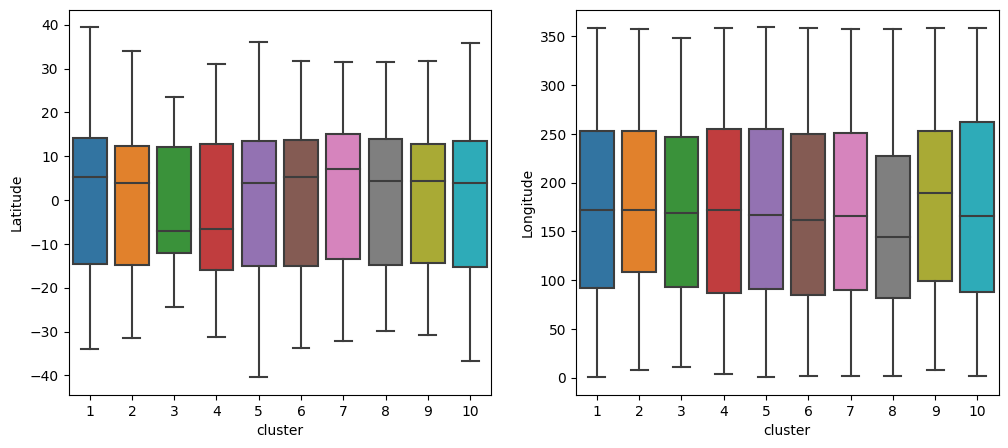

In [71]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='cluster', y='Latitude', data=link)
plt.subplot(1, 2, 2)
sns.boxplot(x='cluster', y='Longitude', data=link)
plt.show()

<ipython-input-73-b41fbd472380>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  link.resample('M')['cluster'].value_counts().unstack().plot(kind='bar', stacked=True)


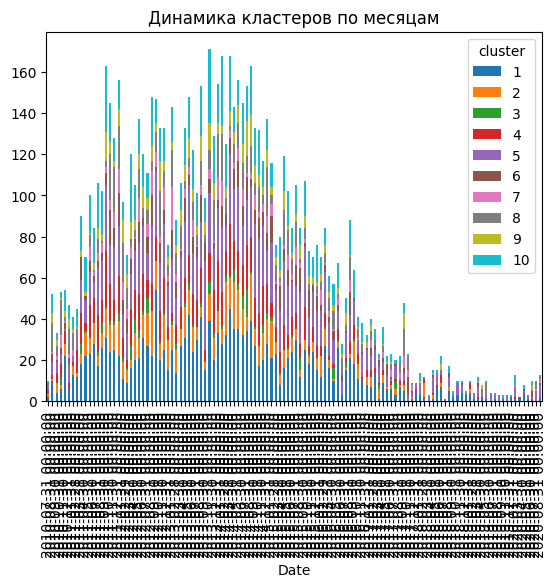

In [73]:
link['Date'] = pd.to_datetime(link['Date'])
link.set_index('Date', inplace=True)

# Распределение кластеров по времени
link.resample('ME')['cluster'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title('Динамика кластеров по месяцам')
plt.show()

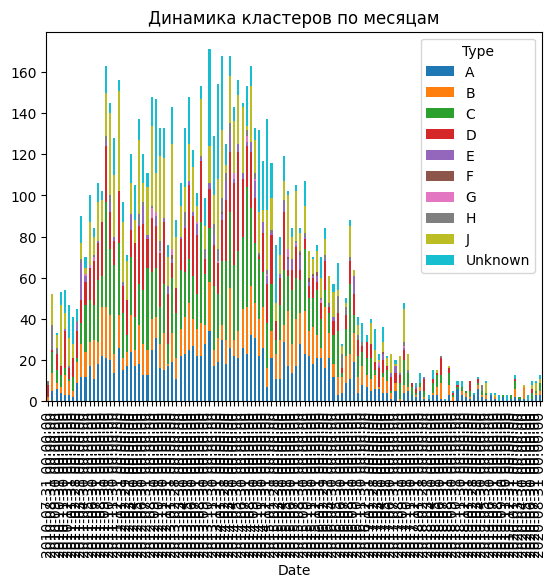

In [76]:
# Распределение кластеров по времени
link.resample('ME')['Type'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title('Динамика кластеров по месяцам')
plt.show()

In [83]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score,fowlkes_mallows_score

ari = adjusted_rand_score(link['Type'], link['cluster'])
nmi = normalized_mutual_info_score(link['Type'], link['cluster'])
print(f"ARI = {ari:.2f}, NMI = {nmi:.2f}")
# Чем ближе к 1, тем лучше кластеры соответствуют типам

fmi = fowlkes_mallows_score(link['Type'], link['cluster'])
print(f"FMI: {fmi:.3f}")

ARI = 0.12, NMI = 0.21
FMI: 0.250


In [80]:
from scipy.stats import chi2_contingency

# Создаем таблицу сопряженности
contingency_table = pd.crosstab(link['Type'], link['cluster'])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"p-value = {p:.3f}")
# p < 0.05 → связь значима

p-value = 0.000


In [84]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(link['Type'], link['cluster'])
chi2, _, _, _ = chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"Cramer’s V: {cramers_v:.3f}")

Cramer’s V: 0.330


In [85]:
from sklearn.metrics import homogeneity_score, completeness_score
homogeneity = homogeneity_score(link['Type'], link['cluster'])
completeness = completeness_score(link['Type'], link['cluster'])
print(f"Homogeneity: {homogeneity:.3f}, Completeness: {completeness:.3f}")

Homogeneity: 0.220, Completeness: 0.200


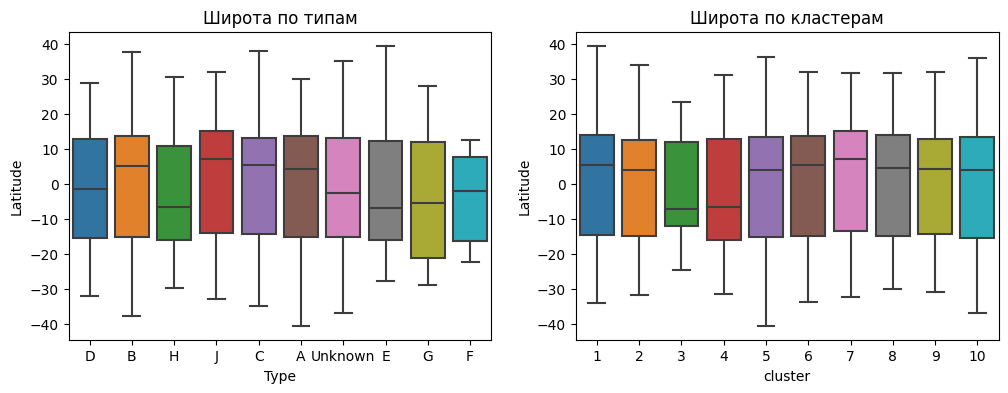

In [98]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=link, x='Type', y='Latitude')
plt.title('Широта по типам')

plt.subplot(1, 2, 2)
sns.boxplot(data=link, x='cluster', y='Latitude')
plt.title('Широта по кластерам')
plt.show()

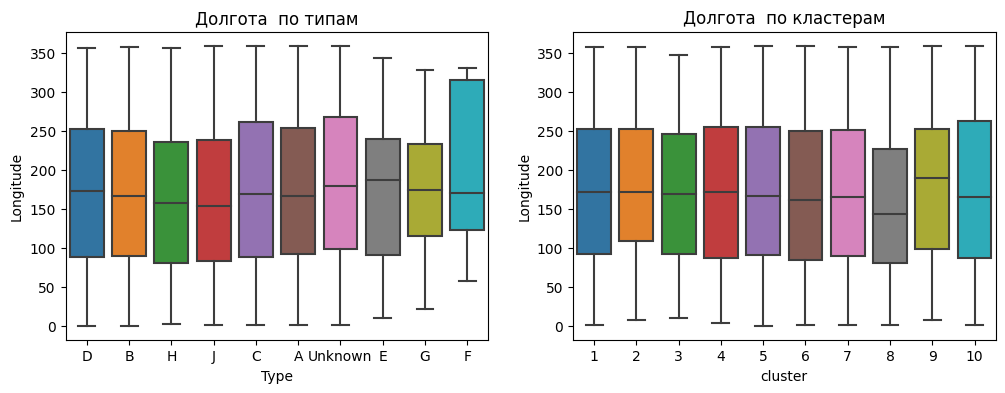

In [99]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=link, x='Type', y='Longitude')
plt.title('Долгота  по типам')

plt.subplot(1, 2, 2)
sns.boxplot(data=link, x='cluster', y='Longitude')
plt.title('Долгота  по кластерам')
plt.show()

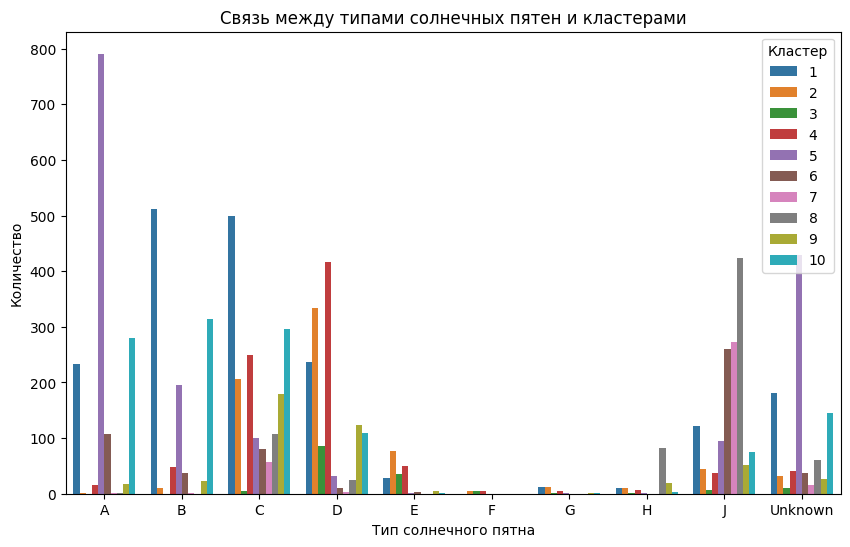

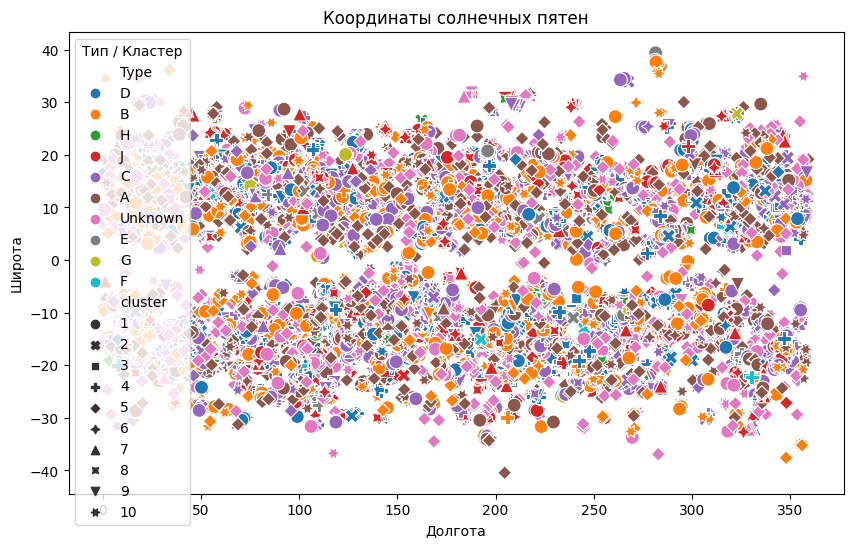

In [55]:
#  Визуализация связи между типами и кластерами
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_data, x='Type', y='Count', hue='cluster')
plt.title('Связь между типами солнечных пятен и кластерами')
plt.xlabel('Тип солнечного пятна')
plt.ylabel('Количество')
plt.legend(title='Кластер')
plt.show()

#  Анализ координат по типам и кластерам
plt.figure(figsize=(10, 6))
sns.scatterplot(data=link, x='Longitude', y='Latitude', hue='Type', style='cluster', s=100)
plt.title('Координаты солнечных пятен')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Тип / Кластер')
plt.show()

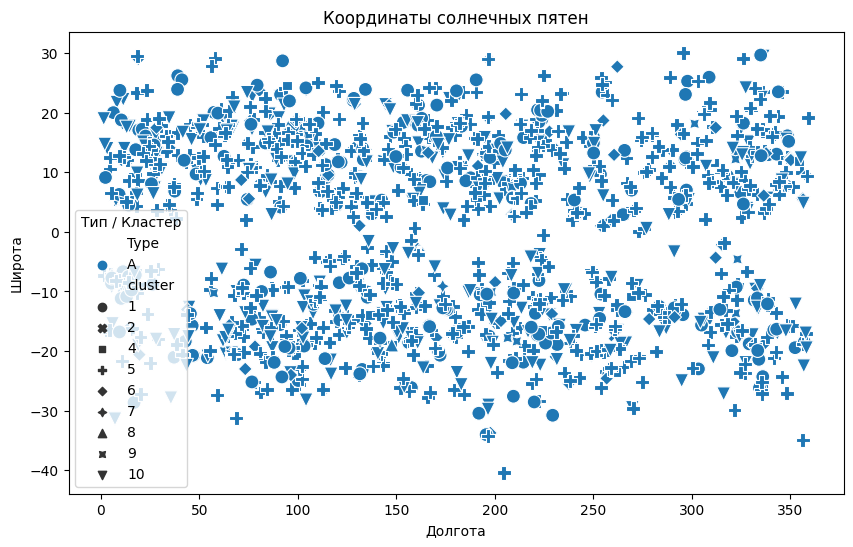

In [59]:
link_A = link[link['Type'] == 'A']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=link_A, x='Longitude', y='Latitude', hue='Type', style='cluster', s=100)
plt.title('Координаты солнечных пятен')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Тип / Кластер')
plt.show()

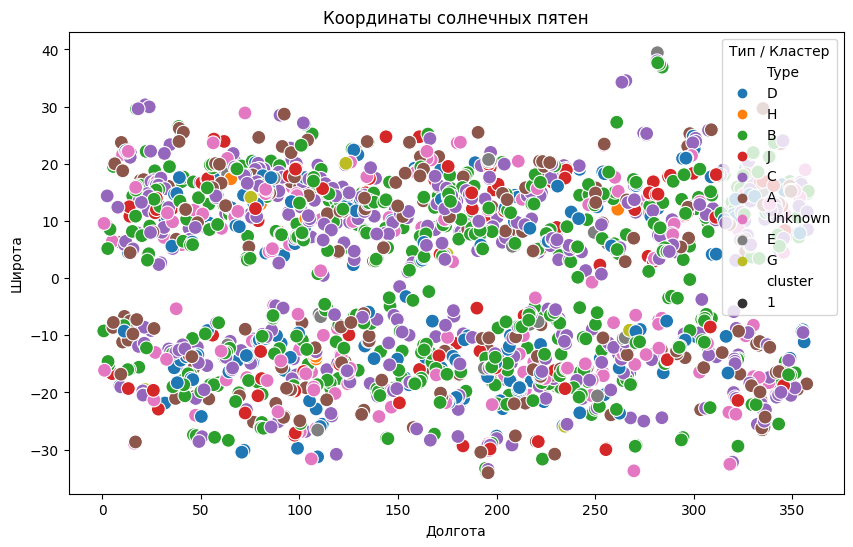

In [60]:
link_1 = link[link['cluster'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=link_1, x='Longitude', y='Latitude', hue='Type', style='cluster', s=100)
plt.title('Координаты солнечных пятен')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='Тип / Кластер')
plt.show()

In [11]:
link

,fname,Date,Time,Latitude,Longitude,Type,cluster,class_encoded,cluster_encoded,tsne_x,tsne_y,pca_x,pca_y,date_encoded,time_encoded
0,201007230452_63,2010-07-23,04:52,-23.565131,200.328655,D,4,3,3,-98.879372,7.290342,-1053.713313,27.946298,0,130
1,201007240414_63,2010-07-24,04:14,-23.933526,201.274268,D,2,3,1,-98.865166,7.292000,-1052.712912,28.894306,1,92
2,201007250447_64,2010-07-25,04:47,23.339903,149.048761,B,5,1,4,-99.156067,-2.338660,-1051.750485,-23.666881,2,125
3,201007250447_63,2010-07-25,04:47,-23.509269,201.557542,D,2,3,1,-98.853157,7.291942,-1051.713098,29.174345,2,125
4,201007260349_63,2010-07-26,03:49,-23.032369,202.530956,D,10,3,9,-98.837433,7.293351,-1050.713176,30.144133,3,67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8493,202008120532_31,2020-08-12,05:32,23.744530,23.202173,A,5,0,4,108.659378,24.330894,1371.223551,-150.009865,2425,170
8494,202008120532_33,2020-08-12,05:32,-19.017301,296.952145,B,5,1,4,93.249466,33.327393,1371.303049,124.037812,2425,170
8495,202008180351_34,2020-08-18,03:51,18.293351,296.295343,C,5,2,4,93.705971,33.018143,1372.281544,123.115001,2426,69
8496,202008190344_35,2020-08-19,03:44,15.355416,254.371843,Unknown,10,9,9,94.503922,32.607674,1373.274803,81.213292,2427,62


In [51]:
observe['Type'].value_counts()

Type
C          1782
A          1450
J          1388
D          1377
B          1141
Unknown     978
E           202
H           134
G            34
F            12
Name: count, dtype: int64

In [52]:
clust['cluster'].value_counts()

cluster
1     1833
5     1645
10    1226
4      873
2      732
8      701
6      538
9      449
7      351
3      150
Name: count, dtype: int64